# Part 1 — Applications & Examples

Six examples from [Probability for Computer Scientists](https://chrispiech.github.io/probabilityForComputerScientists/) that apply Part 1 concepts:

| # | Example | Key Concepts |
|---|---------|-------------|
| 1 | Enigma Machine | Counting, Combinations |
| 2 | Serendipity | Complement, Equally Likely Outcomes |
| 3 | Random Shuffles | Permutations, Log Probabilities |
| 4 | Random Graphs | Combinations, Conditional Counting |
| 5 | Set Diversity (Gini Impurity) | Equally Likely Outcomes, Complement |
| 6 | Bacteria Evolution | Law of Total Probability, Bayes' Theorem |

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import comb, factorial, prod
from decimal import Decimal, getcontext
import networkx as nx

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

---
## 1. Enigma Machine

One of the very first computers was built to break the Nazi "Enigma" codes in WW2.
The machine had **three rotors** (each with 26 positions) and a **plugboard** that swapped letter pairs with wires.

Every day the Nazis chose a new configuration; if the Allies could figure it out, they could read all enemy messages.

### Rotor configurations

Each of the 3 rotors can be set to one of 26 positions (Step Rule):

$$\text{Rotor configs} = 26^3 = 17{,}576$$

In [2]:
rotor_configs = 26 ** 3
print(f"Rotor configurations: 26³ = {rotor_configs:,}")

Rotor configurations: 26³ = 17,576


### Plugboard wires

The plugboard can connect any pair of letters with a wire.  
Wires are **indistinct** and each letter can have at most one wire.

| Wires $k$ | Formula | Count |
|-----------|---------|-------|
| 1 | $\binom{26}{2}$ | 325 |
| 2 | $\frac{\binom{26}{2}\binom{24}{2}}{2!}$ | 44,850 |
| 3 | $\frac{\binom{26}{2}\binom{24}{2}\binom{22}{2}}{3!}$ | 3,453,450 |
| $k$ (general) | $\displaystyle\frac{\prod_{i=1}^{k}\binom{28-2i}{2}}{k!}$ | — |

For **arbitrary** number of wires (0 to 13):

$$\text{Total}_{\text{plugboard}} = \sum_{k=0}^{13} \frac{\prod_{i=1}^{k}\binom{28-2i}{2}}{k!}$$

In [3]:
def plugboard_ways(k):
    """Number of ways to place exactly k wires on a 26-letter plugboard."""
    numerator = prod(comb(28 - 2*i, 2) for i in range(1, k + 1))
    return numerator // factorial(k)

# Compute for each k and accumulate
wire_counts = {k: plugboard_ways(k) for k in range(14)}
total_plugboard = sum(wire_counts.values())

print("Wires (k) │ Configurations")
print("──────────┼───────────────────")
for k, c in wire_counts.items():
    print(f"    {k:2d}    │ {c:>25,}")
print(f"{'':10s}├───────────────────")
print(f"   Total  │ {total_plugboard:>25,}")

Wires (k) │ Configurations
──────────┼───────────────────
     0    │                         1
     1    │                       325
     2    │                    44,850
     3    │                 3,453,450
     4    │               164,038,875
     5    │             5,019,589,575
     6    │           100,391,791,500
     7    │         1,305,093,289,500
     8    │        10,767,019,638,375
     9    │        53,835,098,191,875
    10    │       150,738,274,937,250
    11    │       205,552,193,096,250
    12    │       102,776,096,548,125
    13    │         7,905,853,580,625
          ├───────────────────
   Total  │       532,985,208,200,576


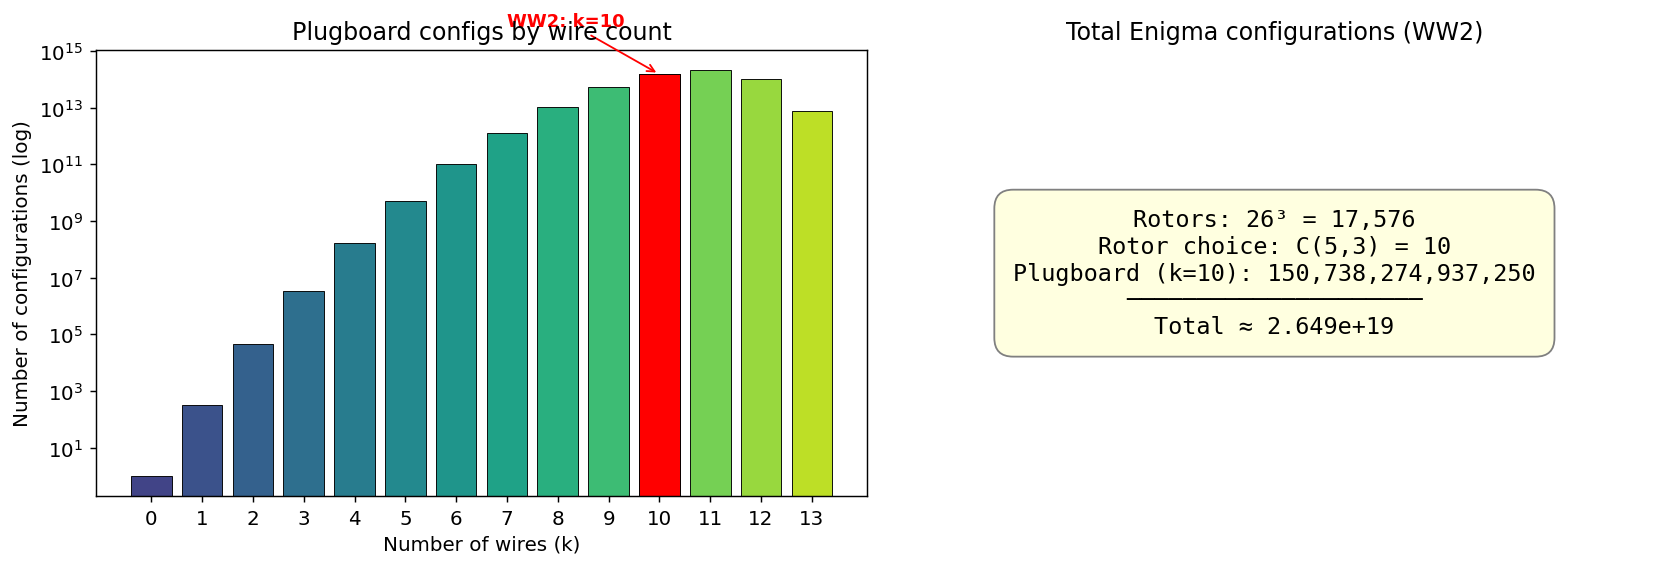

In [4]:
# Visualize plugboard configurations by number of wires (log scale)
ks = list(wire_counts.keys())
counts = list(wire_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Bar chart (log scale)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 14))
axes[0].bar(ks, counts, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Number of wires (k)')
axes[0].set_ylabel('Number of configurations (log)')
axes[0].set_title('Plugboard configs by wire count')
axes[0].set_xticks(ks)

# Highlight the actual WW2 setting: k=10
ww2_k = 10
ww2_count = wire_counts[ww2_k]
axes[0].bar([ww2_k], [ww2_count], color='red', edgecolor='black', linewidth=0.5)
axes[0].annotate(f'WW2: k={ww2_k}', xy=(ww2_k, ww2_count),
                 xytext=(ww2_k - 3, ww2_count * 50),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red', fontweight='bold')

# Total configurations with rotors & rotor choice
rotor_choice = comb(5, 3)  # choose 3 rotors from 5
ww2_plugboard = wire_counts[10]
total_enigma = rotor_configs * ww2_plugboard * rotor_choice

text = (f"Rotors: 26³ = {rotor_configs:,}\n"
        f"Rotor choice: C(5,3) = {rotor_choice}\n"
        f"Plugboard (k=10): {ww2_plugboard:,}\n"
        f"─────────────────────\n"
        f"Total ≈ {total_enigma:.3e}")
axes[1].text(0.5, 0.5, text, transform=axes[1].transAxes,
             fontsize=13, va='center', ha='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', edgecolor='gray'))
axes[1].set_title('Total Enigma configurations (WW2)')
axes[1].axis('off')

fig.tight_layout()
plt.show()

---
## 2. Serendipity

What is the probability of a serendipitous encounter with a friend?

- **Population**: $N = 17{,}000$ (e.g. Stanford students)
- **Friends**: $F = 150$
- **People you see**: $n = 100$

### Complement approach

$$P(\text{see } \geq 1 \text{ friend}) = 1 - P(\text{see 0 friends}) = 1 - \frac{\binom{N-F}{n}}{\binom{N}{n}}$$

The denominator counts all ways to choose $n$ people from $N$;
the numerator counts ways to choose $n$ people from the $N - F$ non-friends.

In [5]:
from scipy.stats import hypergeom

N = 17_000   # total population
F = 150      # friends
n = 100      # people you see

# P(see 0 friends) = C(N-F, n) / C(N, n)
p_zero = hypergeom.pmf(0, N, F, n)
p_at_least_one = 1 - p_zero

print(f"P(see ≥ 1 friend) = 1 - C({N-F},{n})/C({N},{n})")
print(f"                  = 1 - {p_zero:.6f}")
print(f"                  = {p_at_least_one:.6f}  ({p_at_least_one*100:.2f}%)")

P(see ≥ 1 friend) = 1 - C(16850,100)/C(17000,100)
                  = 1 - 0.411120
                  = 0.588880  (58.89%)


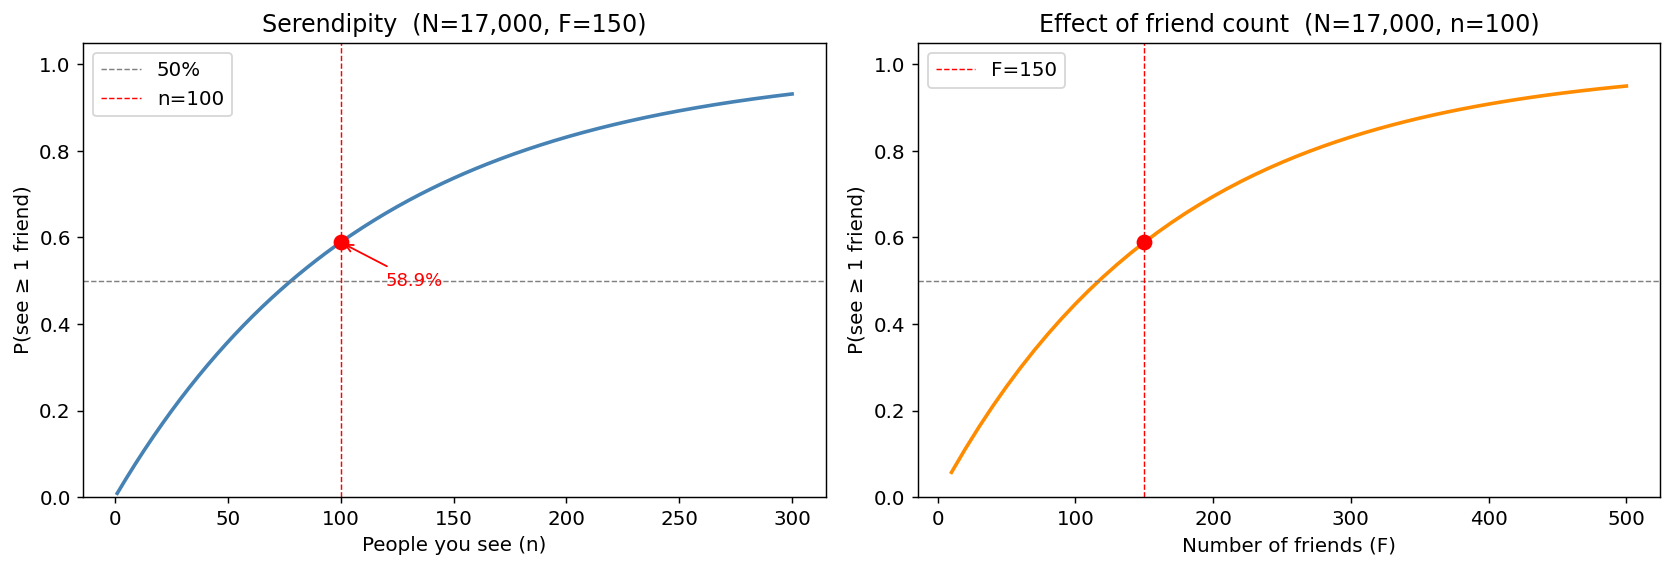

In [6]:
# Explore: how does P(≥1 friend) change with the number of people you see?
people_seen = np.arange(1, 301)
probs = [1 - hypergeom.pmf(0, N, F, ns) for ns in people_seen]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: P vs people seen
axes[0].plot(people_seen, probs, color='steelblue', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50%')
axes[0].axvline(n, color='red', linestyle='--', linewidth=0.8, label=f'n={n}')
axes[0].scatter([n], [p_at_least_one], color='red', zorder=5, s=60)
axes[0].annotate(f'{p_at_least_one:.1%}', xy=(n, p_at_least_one),
                 xytext=(n+20, p_at_least_one - 0.1),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')
axes[0].set_xlabel('People you see (n)')
axes[0].set_ylabel('P(see ≥ 1 friend)')
axes[0].set_title(f'Serendipity  (N={N:,}, F={F})')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Right: vary number of friends with n=100
friends_range = np.arange(10, 501, 10)
probs_f = [1 - hypergeom.pmf(0, N, f, n) for f in friends_range]
axes[1].plot(friends_range, probs_f, color='darkorange', linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(F, color='red', linestyle='--', linewidth=0.8, label=f'F={F}')
axes[1].scatter([F], [p_at_least_one], color='red', zorder=5, s=60)
axes[1].set_xlabel('Number of friends (F)')
axes[1].set_ylabel('P(see ≥ 1 friend)')
axes[1].set_title(f'Effect of friend count  (N={N:,}, n={n})')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

---
## 3. Random Shuffles

If you riffle-shuffle a deck 7 times, with near certainty **your exact ordering has never been seen before!**

### How many orderings?

$$52! = 80{,}658{,}175{,}170{,}943{,}878{,}571{,}660{,}636{,}856{,}403{,}766{,}975\ldots \approx 8.07 \times 10^{67}$$

### How many shuffles in history?

Overestimate: 7 billion people shuffling once per second since the 15th century:

$$n = 7 \times 10^9 \times 16{,}472{,}828{,}422 \approx 10^{20}$$

### Is your ordering unique?

$$P(\text{unique}) = \left(\frac{52! - 1}{52!}\right)^{n}$$

Using **log probabilities** (because the numbers are astronomically large):

$$\log P(U) = n \cdot \log\!\left(\frac{52! - 1}{52!}\right) \approx 10^{20} \cdot (-1.24 \times 10^{-68}) = -1.24 \times 10^{-48}$$

$$P(U) = e^{-1.24 \times 10^{-48}} \approx 1 - 1.24 \times 10^{-48}$$

In [7]:
# Compute using Python's decimal library for extreme precision
import math

n_shuffles = int(1e20)
card_perms = math.factorial(52)

getcontext().prec = 100
log_numer = Decimal(card_perms - 1).ln()
log_denom = Decimal(card_perms).ln()
log_ratio = log_numer - log_denom

print(f"52! = {card_perms}")
print(f"    ≈ {card_perms:.3e}")
print(f"\nlog(52!-1 / 52!) = {log_ratio}")
print(f"\nlog P(unique) = 10^20 × {log_ratio}")
print(f"              = {Decimal(n_shuffles) * log_ratio}")
print(f"\nP(unique) ≈ 1 − 1.24 × 10⁻⁴⁸  (essentially 1)")
print("\nYour shuffle is almost certainly unique in all of human history!")

52! = 80658175170943878571660636856403766975289505440883277824000000000000
    ≈ 8.066e+67

log(52!-1 / 52!) = -1.23979993085714859239503419890E-68

log P(unique) = 10^20 × -1.23979993085714859239503419890E-68
              = -1.2397999308571485923950341989000000000000000000000E-48

P(unique) ≈ 1 − 1.24 × 10⁻⁴⁸  (essentially 1)

Your shuffle is almost certainly unique in all of human history!


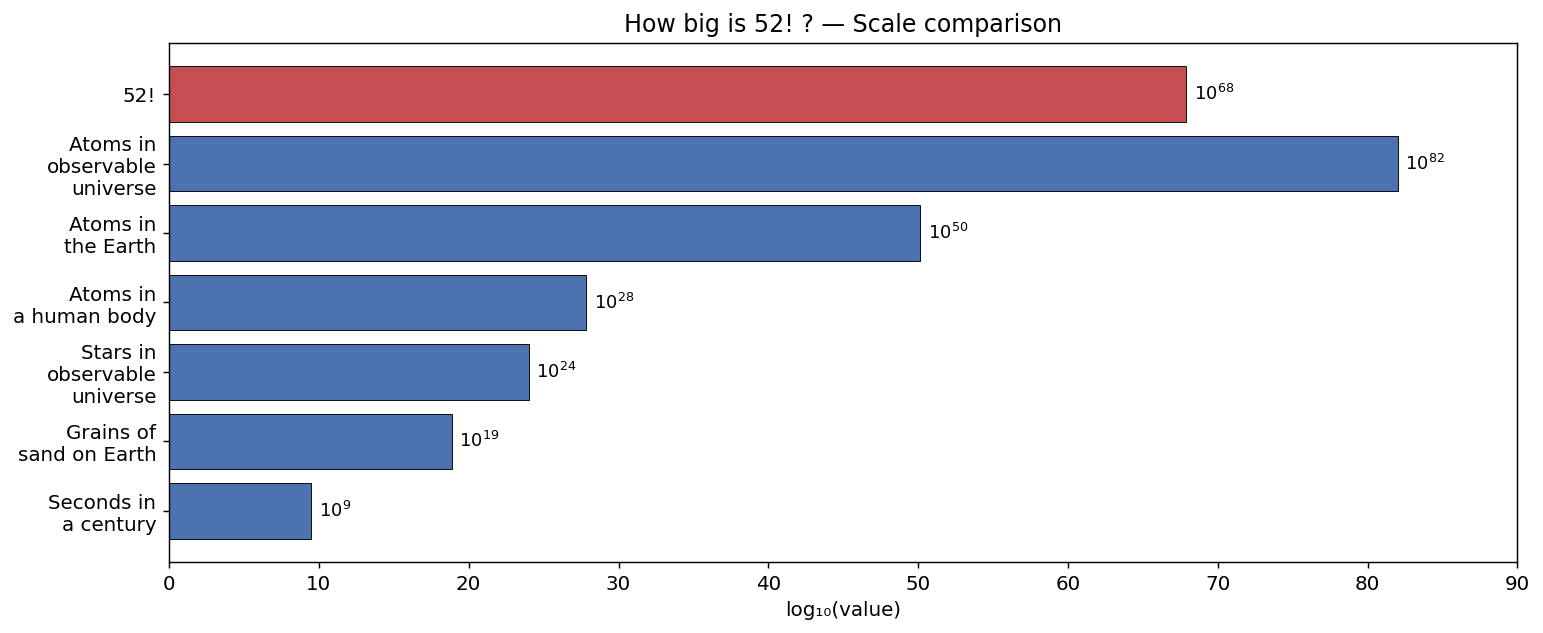

In [8]:
# Visualize: compare 52! to familiar large numbers
comparisons = {
    'Seconds in\na century': 3.156e9,
    'Grains of\nsand on Earth': 7.5e18,
    'Stars in\nobservable\nuniverse': 1e24,
    'Atoms in\na human body': 7e27,
    'Atoms in\nthe Earth': 1.33e50,
    'Atoms in\nobservable\nuniverse': 1e82,
    '52!': float(card_perms),
}

fig, ax = plt.subplots(figsize=(12, 5))
labels = list(comparisons.keys())
values = list(comparisons.values())
log_values = [np.log10(v) for v in values]

colors_bar = ['#4c72b0'] * len(labels)
colors_bar[labels.index('52!')] = '#c44e52'

bars = ax.barh(labels, log_values, color=colors_bar, edgecolor='black', linewidth=0.5)
for bar, lv in zip(bars, log_values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'10$^{{{lv:.0f}}}$', va='center', fontsize=10)

ax.set_xlabel('log₁₀(value)')
ax.set_title('How big is 52! ? — Scale comparison')
ax.set_xlim(0, 90)
fig.tight_layout()
plt.show()

---
## 4. Random Graphs

Explore the density of randomly generated networks (from Stanford Midterm Fall 2022).

A network has $V = 10$ nodes and $E = 12$ random undirected edges (no self-loops).

### Count edge locations

$$\text{Possible edge locations} = \binom{V}{2} = \binom{10}{2} = 45$$

### Count ways to place 12 edges

$$\binom{45}{12} = \text{ways to choose 12 edge locations}$$

### Probability of node degree $i$

Select a node uniformly at random. It has 9 possible incident edges.

$$P(\text{degree} = i) = \frac{\binom{9}{i}\binom{k-9}{12-i}}{\binom{k}{12}}, \quad k = 45$$

In [9]:
V, E = 10, 12
k = comb(V, 2)  # possible edge locations

print(f"Nodes: {V},  Edges: {E}")
print(f"Possible edge locations: C({V},2) = {k}")
print(f"Ways to place {E} edges: C({k},{E}) = {comb(k, E):,}")

# Degree distribution
max_deg = V - 1  # max connections from one node
degree_probs = []
for i in range(max_deg + 1):
    if E - i > k - (V - 1) or E - i < 0:
        degree_probs.append(0)
    else:
        p = comb(max_deg, i) * comb(k - max_deg, E - i) / comb(k, E)
        degree_probs.append(p)

print(f"\nDegree distribution for a random node:")
print(f"{'Degree i':>10s} │ {'P(deg = i)':>12s}")
print(f"{'─'*10:s}─┼─{'─'*12:s}")
for i, p in enumerate(degree_probs):
    bar = '█' * int(p * 50)
    print(f"{i:>10d} │ {p:>12.6f}  {bar}")

Nodes: 10,  Edges: 12
Possible edge locations: C(10,2) = 45
Ways to place 12 edges: C(45,12) = 28,760,021,745

Degree distribution for a random node:
  Degree i │   P(deg = i)
───────────┼─────────────
         0 │     0.043521  ██
         1 │     0.188013  █████████
         2 │     0.318175  ███████████████
         3 │     0.274966  █████████████
         4 │     0.132573  ██████
         5 │     0.036572  █
         6 │     0.005689  
         7 │     0.000472  
         8 │     0.000018  
         9 │     0.000000  


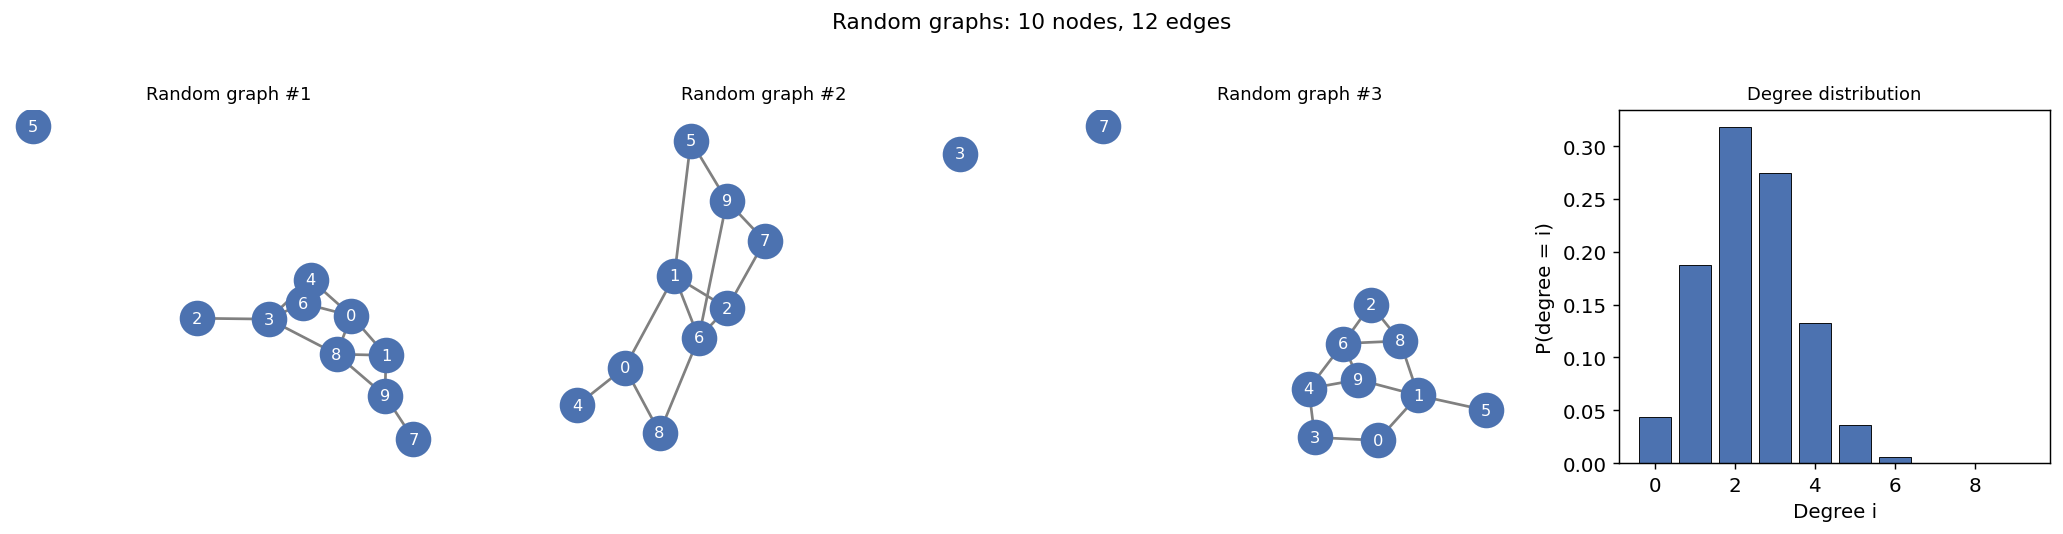

In [10]:
# Visualize: generate 3 random graphs + degree distribution
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

import random as _rnd
for idx in range(3):
    G = nx.gnm_random_graph(V, E, seed=_rnd.Random(42 + idx))
    pos = nx.spring_layout(G, seed=42 + idx)
    nx.draw(G, pos, ax=axes[idx], with_labels=True,
            node_color='#4c72b0', node_size=350, font_size=9,
            font_color='white', edge_color='gray', width=1.5)
    axes[idx].set_title(f'Random graph #{idx+1}', fontsize=10)

# Degree distribution
degrees = range(max_deg + 1)
axes[3].bar(degrees, degree_probs, color='#4c72b0', edgecolor='black', linewidth=0.5)
axes[3].set_xlabel('Degree i')
axes[3].set_ylabel('P(degree = i)')
axes[3].set_title('Degree distribution', fontsize=10)
axes[3].set_xticks(range(0, max_deg + 1, 2))

fig.suptitle(f'Random graphs: {V} nodes, {E} edges', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

---
## 5. Set Diversity (Gini Impurity)

The **Gini Impurity** of a set measures how likely it is that two randomly chosen items (with replacement) are **different**.

$$G = 1 - P(\text{same}) = 1 - \sum_i \left(\frac{n_i}{n}\right)^2$$

where $n_i$ = count of type $i$, $n$ = total count.

Used in **Decision Trees** and **Random Forests** to decide which feature to split on — choose the split that reduces Gini Impurity the most.

### Example sets from the course

**Set a)** 6 squares + 1 triangle → $P(\text{same}) = \frac{6^2 + 1^2}{7^2} = \frac{37}{49}$ → $G = \frac{12}{49}$

**Set b)** 4 squares + 2 triangles + 1 star → $P(\text{same}) = \frac{4^2 + 2^2 + 1^2}{7^2} = \frac{21}{49}$ → $G = \frac{28}{49}$

In [11]:
def gini_impurity(counts):
    """Gini impurity for a set with given type counts."""
    n = sum(counts)
    return 1 - sum((c / n) ** 2 for c in counts)

# Course examples
set_a = {'squares': 6, 'triangles': 1}
set_b = {'squares': 4, 'triangles': 2, 'stars': 1}

g_a = gini_impurity(list(set_a.values()))
g_b = gini_impurity(list(set_b.values()))

print(f"Set a) {set_a}")
print(f"  P(same) = {1-g_a:.6f} = 37/49")
print(f"  Gini    = {g_a:.6f} = 12/49")
print(f"\nSet b) {set_b}")
print(f"  P(same) = {1-g_b:.6f} = 21/49")
print(f"  Gini    = {g_b:.6f} = 28/49")

# Decision tree split example
left = {'squares': 2, 'triangles': 5}
right = {'squares': 2, 'stars': 1}
g_left = gini_impurity(list(left.values()))
g_right = gini_impurity(list(right.values()))
print(f"\nDecision tree split:")
print(f"  Left child  {left}  → G_L = {g_left:.4f}")
print(f"  Right child {right} → G_R = {g_right:.4f}")
print(f"  max(G_L, G_R) = {max(g_left, g_right):.4f}")

Set a) {'squares': 6, 'triangles': 1}
  P(same) = 0.755102 = 37/49
  Gini    = 0.244898 = 12/49

Set b) {'squares': 4, 'triangles': 2, 'stars': 1}
  P(same) = 0.428571 = 21/49
  Gini    = 0.571429 = 28/49

Decision tree split:
  Left child  {'squares': 2, 'triangles': 5}  → G_L = 0.4082
  Right child {'squares': 2, 'stars': 1} → G_R = 0.4444
  max(G_L, G_R) = 0.4444


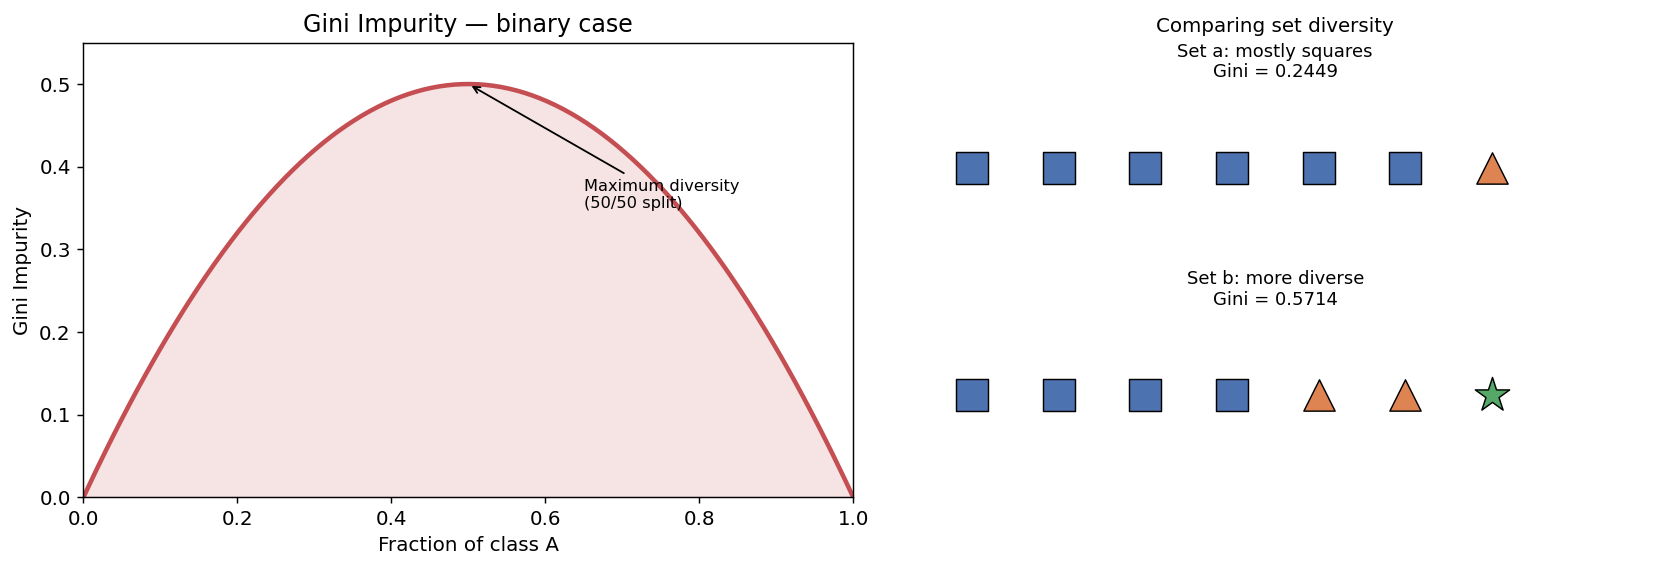

In [12]:
# Visualize Gini impurity for binary case (fraction of type A)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: Gini curve for binary classification
p = np.linspace(0, 1, 200)
gini = 2 * p * (1 - p)  # simplified for 2 classes: 1 - p² - (1-p)²
axes[0].plot(p, gini, linewidth=2.5, color='#c44e52')
axes[0].fill_between(p, gini, alpha=0.15, color='#c44e52')
axes[0].set_xlabel('Fraction of class A')
axes[0].set_ylabel('Gini Impurity')
axes[0].set_title('Gini Impurity — binary case')
axes[0].annotate('Maximum diversity\n(50/50 split)', xy=(0.5, 0.5),
                 xytext=(0.65, 0.35), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='black'))
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 0.55)

# Right panel: visual comparison of set a vs set b
def draw_shapes(ax, counts_dict, title, gini_val):
    """Draw a row of shapes representing the set."""
    shape_colors = {'squares': '#4c72b0', 'triangles': '#dd8452', 'stars': '#55a868'}
    markers = {'squares': 's', 'triangles': '^', 'stars': '*'}
    sizes = {'squares': 300, 'triangles': 300, 'stars': 400}
    x = 0
    for shape, count in counts_dict.items():
        for _ in range(count):
            ax.scatter(x, 0.5, marker=markers[shape], s=sizes[shape],
                      color=shape_colors[shape], edgecolor='black', linewidth=0.8, zorder=5)
            x += 1
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title}\nGini = {gini_val:.4f}', fontsize=10)
    ax.axis('off')

# Create inset axes for the shape sets
ax_a = axes[1].inset_axes([0.05, 0.55, 0.9, 0.35])
ax_b = axes[1].inset_axes([0.05, 0.05, 0.9, 0.35])
draw_shapes(ax_a, set_a, 'Set a: mostly squares', g_a)
draw_shapes(ax_b, set_b, 'Set b: more diverse', g_b)
axes[1].set_title('Comparing set diversity', fontsize=11)
axes[1].axis('off')

fig.tight_layout()
plt.show()

---
## 6. Bacteria Evolution

Anti-biotic resistance through the lens of probability.

- **Population**: 1,000,000 bacteria
- **10%** have a resistance mutation ($M$)
- $P(\text{survive} \mid M) = 0.20$
- $P(\text{survive} \mid M^C) = 0.01$

### Q1: What fraction of bacteria survive?

By the **Law of Total Probability**:

$$P(E) = P(E|M)P(M) + P(E|M^C)P(M^C) = 0.20 \cdot 0.10 + 0.01 \cdot 0.90 = 0.029$$

### Q2: Of those that survive, what fraction has the mutation?

By **Bayes' Theorem**:

$$P(M|E) = \frac{P(E|M)P(M)}{P(E)} = \frac{0.20 \times 0.10}{0.029} \approx 0.69$$

After antibiotics, **69%** of surviving bacteria carry the mutation (up from 10%)!

In [13]:
# Parameters
pop = 1_000_000
p_M = 0.10              # fraction with mutation
p_survive_M = 0.20      # survival rate with mutation
p_survive_noM = 0.01    # survival rate without mutation

# Law of Total Probability
p_survive = p_survive_M * p_M + p_survive_noM * (1 - p_M)

# Bayes' Theorem
p_M_given_survive = (p_survive_M * p_M) / p_survive

# Counts
mutant_before = int(pop * p_M)
normal_before = pop - mutant_before
mutant_survive = int(mutant_before * p_survive_M)
normal_survive = int(normal_before * p_survive_noM)
total_survive = mutant_survive + normal_survive

print("=== Law of Total Probability ===")
print(f"P(survive) = P(E|M)·P(M) + P(E|Mᶜ)·P(Mᶜ)")
print(f"           = {p_survive_M}×{p_M} + {p_survive_noM}×{1-p_M}")
print(f"           = {p_survive}")
print(f"\n=== Bayes' Theorem ===")
print(f"P(M|survive) = P(E|M)·P(M) / P(E)")
print(f"             = {p_survive_M}×{p_M} / {p_survive}")
print(f"             = {p_M_given_survive:.4f}  ({p_M_given_survive*100:.1f}%)")
print(f"\n=== Population counts ===")
print(f"Before: {mutant_before:>10,} mutant  +  {normal_before:>10,} normal  =  {pop:>10,}")
print(f"After:  {mutant_survive:>10,} mutant  +  {normal_survive:>10,} normal  =  {total_survive:>10,}")

=== Law of Total Probability ===
P(survive) = P(E|M)·P(M) + P(E|Mᶜ)·P(Mᶜ)
           = 0.2×0.1 + 0.01×0.9
           = 0.029000000000000005

=== Bayes' Theorem ===
P(M|survive) = P(E|M)·P(M) / P(E)
             = 0.2×0.1 / 0.029000000000000005
             = 0.6897  (69.0%)

=== Population counts ===
Before:    100,000 mutant  +     900,000 normal  =   1,000,000
After:      20,000 mutant  +       9,000 normal  =      29,000


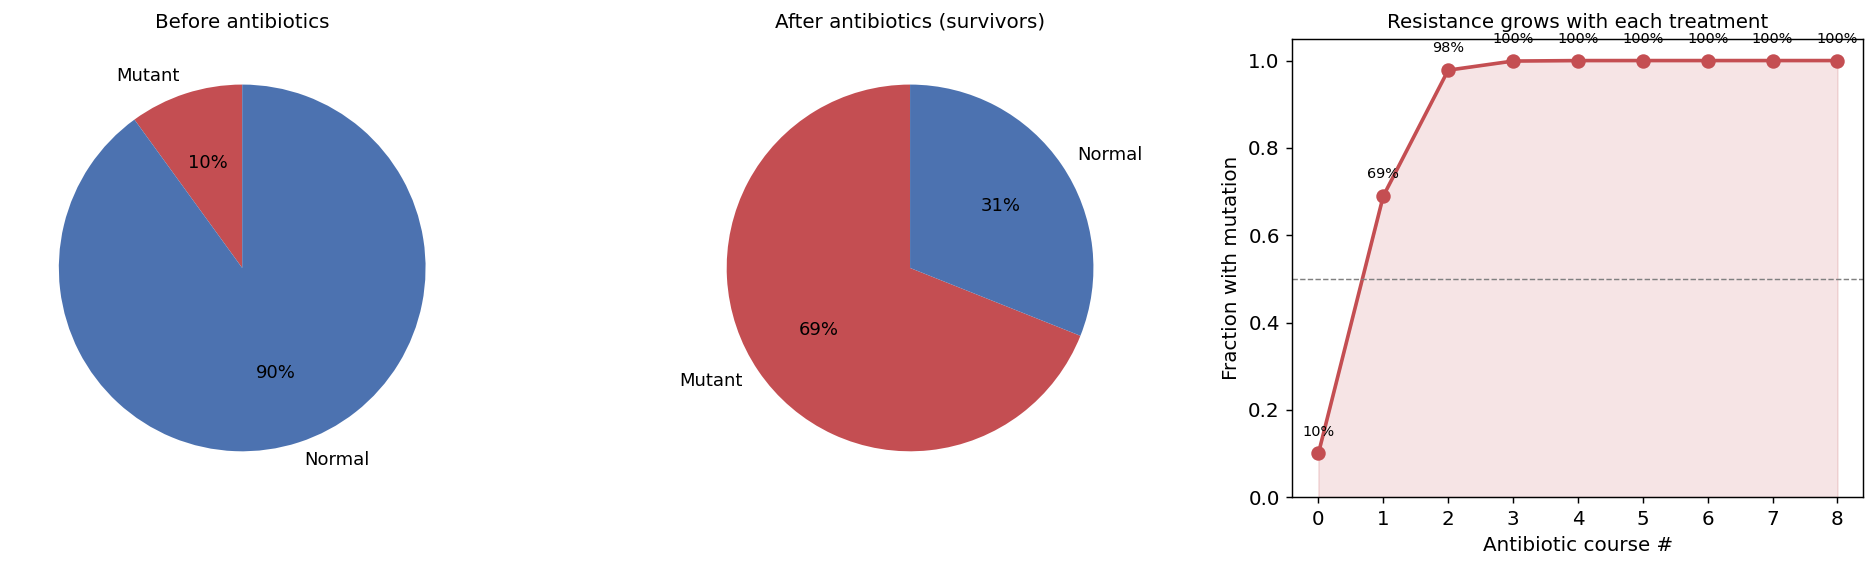

In [14]:
# Visualize the evolution of resistance
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Before vs After pie charts
colors_pie = ['#c44e52', '#4c72b0']
labels_pie = ['Mutant', 'Normal']

axes[0].pie([mutant_before, normal_before], labels=labels_pie,
            colors=colors_pie, autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Before antibiotics', fontsize=11)

axes[1].pie([mutant_survive, normal_survive], labels=labels_pie,
            colors=colors_pie, autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('After antibiotics (survivors)', fontsize=11)

# Panel 3: Multi-generation simulation
n_generations = 8
mutant_frac = [p_M]

frac = p_M
for _ in range(n_generations):
    # Each generation: apply antibiotics, then population regrows to same size
    p_surv = p_survive_M * frac + p_survive_noM * (1 - frac)
    frac = (p_survive_M * frac) / p_surv  # Bayes update
    mutant_frac.append(frac)

gens = range(n_generations + 1)
axes[2].plot(gens, mutant_frac, 'o-', color='#c44e52', linewidth=2, markersize=7)
axes[2].fill_between(gens, mutant_frac, alpha=0.15, color='#c44e52')
axes[2].set_xlabel('Antibiotic course #')
axes[2].set_ylabel('Fraction with mutation')
axes[2].set_title('Resistance grows with each treatment', fontsize=11)
axes[2].set_ylim(0, 1.05)
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
for g, f in zip(gens, mutant_frac):
    axes[2].annotate(f'{f:.0%}', (g, f), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=8)

fig.tight_layout()
plt.show()

---
## Summary

| Example | Concepts Used | Key Insight |
|---------|-------------|-------------|
| Enigma Machine | Step rule, Combinations | ≈ 1.59 × 10²⁰ configurations — needed a *computer* to crack |
| Serendipity | Complement, Hypergeometric | Seeing 100 of 17,000 people → ~59% chance of meeting a friend |
| Random Shuffles | Permutations, Log probs | 52! is so huge that every shuffle is unique in history |
| Random Graphs | Combinations, Counting | Degree distribution from combinatorial counting |
| Gini Impurity | Equally likely, Complement | Measures set diversity; powers Decision Tree splits |
| Bacteria Evolution | LOTP, Bayes' Theorem | One course of antibiotics shifts mutation rate 10% → 69% |